In [3]:
import pandas as pd
import numpy as np
import re

# Funzione completa di pulizia del dataset immobiliare
def pulisci_dataset_sale_raw(df):
    df = df.copy()

    # -----------------------------
    # 1. PREZZO → numerico
    # -----------------------------
    if "prezzo" in df.columns:
        df["prezzo"] = (
            df["prezzo"]
            .astype(str)
            .str.replace("€", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.extract(r"(\d+\.?\d*)")[0]
            .astype(float)
        )

    # -----------------------------
    # 2. SUPERFICIE → numerico (m²)
    # -----------------------------
    if "superficie" in df.columns:
        df["superficie_mq"] = (
            df["superficie"]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(float)
        )

    # -----------------------------
    # 3. STANZE → numerico
    # -----------------------------
    if "stanze" in df.columns:
        df["stanze"] = pd.to_numeric(df["stanze"], errors="coerce")

    # -----------------------------
    # 4. BAGNI → numerico
    # -----------------------------
    if "bagni" in df.columns:
        df["bagni"] = pd.to_numeric(df["bagni"], errors="coerce")

    # -----------------------------
    # 5. PIANO → estrazione livello
    # -----------------------------
    def estrai_piano(x):
        if pd.isna(x):
            return np.nan
        x = str(x).lower()
        if "terra" in x:
            return 0
        match = re.search(r"(\d+)", x)
        return int(match.group(1)) if match else np.nan

    if "piano" in df.columns:
        df["piano_num"] = df["piano"].apply(estrai_piano)

    # -----------------------------
    # 6. RIFERIMENTO + DATA ANNUNCIO
    # -----------------------------
    if "Riferimento e Data annuncio" in df.columns:
        # Estrai riferimento
        df["riferimento"] = (
            df["Riferimento e Data annuncio"]
            .astype(str)
            .str.split("-", n=1, expand=True)[0]
            .str.strip()
        )

        # Estrai data
        df["Data_annuncio"] = (
            df["Riferimento e Data annuncio"]
            .astype(str)
            .str.extract(r"(\d{2}/\d{2}/\d{4})")[0]
        )

        df["Data_annuncio"] = pd.to_datetime(
            df["Data_annuncio"],
            format="%d/%m/%Y",
            errors="coerce"
        )

    # -----------------------------
    # 7. TIPOLOGIA → estrai categoria principale
    # -----------------------------
    if "tipologia" in df.columns:
        df["categoria"] = (
            df["tipologia"]
            .astype(str)
            .str.split("|", expand=True)[0]
            .str.strip()
        )

    # -----------------------------
    # 8. NORMALIZZAZIONE TESTO
    # -----------------------------
    colonne_testo = ["description", "tipologia", "piano"]
    for col in colonne_testo:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    return df

In [4]:
#carico il dataset
df = pd.read_csv("sale_raw.csv")

In [5]:
#Pulizia
df_clean = pulisci_dataset_sale_raw(df)

In [6]:
df_clean["prezzo_mq"] = df_clean["prezzo"] / df_clean["superficie_mq"]
df_clean["giorni_annuncio"] = (pd.Timestamp.today() - df_clean["Data_annuncio"]).dt.days

In [8]:
df.columns

Index(['prezzo', 'stanze', 'm2', 'bagni', 'piano', 'description',
       'Riferimento e Data annuncio', 'contratto', 'tipologia', 'superficie',
       'locali', 'totale piani edificio', 'disponibilità',
       'other_characteristics', 'citta', 'quartiere', 'href', 'regione',
       'Posti Auto', 'via', 'unità',
       'Data di inizio lavori e di consegna prevista', 'Uso edificio attuale',
       'altre caratteristiche', 'spese condominio', 'cauzione', 'stato',
       'Efficienza energetica', 'anno di costruzione', 'riscaldamento',
       'Climatizzatore', 'certificazione energetica',
       'Indice prest. energetica rinnovabile',
       'Prestazione energetica del fabbricato', 'spese aggiuntive',
       'Dati catastali', 'Altri dati catastali'],
      dtype='object')

In [16]:
df.describe()

,anno di costruzione
count,3761.000000
mean,1961.636533
std,73.166816
min,1100.000000
25%,1950.000000
50%,1970.000000
75%,2000.000000
max,2023.000000


In [10]:
df.shape

(37087, 37)

In [17]:
df.tail()

,prezzo,stanze,m2,bagni,piano,description,Riferimento e Data annuncio,contratto,tipologia,superficie,...,Efficienza energetica,anno di costruzione,riscaldamento,Climatizzatore,certificazione energetica,Indice prest. energetica rinnovabile,Prestazione energetica del fabbricato,spese aggiuntive,Dati catastali,Altri dati catastali
37082,€ 285.000,4,110m²,1,"3 piani: Interrato (-1), Piano terra, 1°, con ...",CASTELLO in una tranquilla traversa di via Ses...,V/Cast/04/05 - 22/06/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,110 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37083,€ 358.000,5,180m²,3,NaN,"pontassieve collinare, in localita' san prugna...",FI.RARE_1 - 28/06/2023,Vendita,Villa bifamiliare,180 m²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37084,€ 580.000,4,70m²,2,"5°, con ascensore","Firenze, CENTRO STORICO, pressi via dei Lamber...",0074 - 08/07/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,70 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37085,€ 240.000,3,55m²,1,2 piani: da Seminterrato a Piano terra,A poca distanza dalla bellissima spiaggia in s...,1699 - 18/05/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,55 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37086,€ 1.713.230,5,176m²,2,1° piano,"Immersi nelle colline di Sesto Fiorentino, vic...",6954 - 14/07/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,176 m²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37087 entries, 0 to 37086
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   prezzo                                        37087 non-null  object 
 1   stanze                                        37071 non-null  object 
 2   m2                                            36937 non-null  object 
 3   bagni                                         36556 non-null  object 
 4   piano                                         36375 non-null  object 
 5   description                                   37082 non-null  object 
 6   Riferimento e Data annuncio                   37087 non-null  object 
 7   contratto                                     37087 non-null  object 
 8   tipologia                                     37087 non-null  object 
 9   superficie                                    35946 non-null 

In [15]:
df.head(5)

,prezzo,stanze,m2,bagni,piano,description,Riferimento e Data annuncio,contratto,tipologia,superficie,...,Efficienza energetica,anno di costruzione,riscaldamento,Climatizzatore,certificazione energetica,Indice prest. energetica rinnovabile,Prestazione energetica del fabbricato,spese aggiuntive,Dati catastali,Altri dati catastali
0,€ 78.000,3,67m²,1,"Piano terra, con accesso disabili","Vendesi a Valledoria in Via Alessandro Volta, ...",Daniela - 17/12/2022,Vendita,Appartamento | Intera proprietà | Classe immob...,67 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,€ 460.000,3,75m²,2,1°,Nell’esclusivo comprensorio di Punta Aldìa in ...,698 - 31/03/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,75 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,€ 387.000,4,160m²,2,"4° piano, con ascensore, con accesso disabili","Via Morgagni, zona residenziale e silenziosa, ...",Via Morgagni_ - 18/04/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,160 m²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,€ 257.000,5,136m²,2,"4° piano, con ascensore","Nella rinomata Fonsarda, precisamente in via G...",Via Giudicessa_ - 14/04/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,136 m²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,€ 370.000,3,105m²,2,"Piano terra, con accesso disabili",Luminosa villetta bifamiliare semindipendente ...,F3c sud - 31/03/2023,Vendita - Scarica capitolato,Villa bifamiliare | Intera proprietà | Immobil...,105 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
    if "prezzo" in df.columns:
        df["prezzo"] = (
            df["prezzo"]
            .astype(str)
            .str.replace("€", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.extract(r"(\d+\.?\d*)")[0]
            .astype(float)
        )

In [21]:
df["prezzo"]

0          78000.0
1         460000.0
2         387000.0
3         257000.0
4         370000.0
           ...    
37082     285000.0
37083     358000.0
37084     580000.0
37085     240000.0
37086    1713230.0
Name: prezzo, Length: 37087, dtype: float64

In [22]:
 if "superficie" in df.columns:
        df["superficie_mq"] = (
            df["superficie"]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(float)
        )


In [23]:
df["superficie_mq"]

0         67.0
1         75.0
2        160.0
3        136.0
4        105.0
         ...  
37082    110.0
37083    180.0
37084     70.0
37085     55.0
37086    176.0
Name: superficie_mq, Length: 37087, dtype: float64

In [24]:
if "Riferimento e Data annuncio" in df.columns:
        # Estrai riferimento
        df["riferimento"] = (
            df["Riferimento e Data annuncio"]
            .astype(str)
            .str.split("-", n=1, expand=True)[0]
            .str.strip()
        )



In [25]:
df["riferimento"]

0                Daniela
1                    698
2          Via Morgagni_
3        Via Giudicessa_
4                F3c sud
              ...       
37082       V/Cast/04/05
37083          FI.RARE_1
37084               0074
37085               1699
37086               6954
Name: riferimento, Length: 37087, dtype: object

In [27]:
df["Data_annuncio"] = (
            df["Riferimento e Data annuncio"]
            .astype(str)
            .str.extract(r"(\d{2}/\d{2}/\d{4})")[0])


In [28]:
df["Data_annuncio"]

0        17/12/2022
1        31/03/2023
2        18/04/2023
3        14/04/2023
4        31/03/2023
            ...    
37082    22/06/2023
37083    28/06/2023
37084    08/07/2023
37085    18/05/2023
37086    14/07/2023
Name: Data_annuncio, Length: 37087, dtype: object

In [29]:
 df["Data_annuncio"] = pd.to_datetime(
            df["Data_annuncio"],
            format="%d/%m/%Y",
            errors="coerce"
        )




In [30]:
 df["Data_annuncio"]

0       2022-12-17
1       2023-03-31
2       2023-04-18
3       2023-04-14
4       2023-03-31
           ...    
37082   2023-06-22
37083   2023-06-28
37084   2023-07-08
37085   2023-05-18
37086   2023-07-14
Name: Data_annuncio, Length: 37087, dtype: datetime64[ns]

In [31]:
 if "tipologia" in df.columns:
        df["categoria"] = (
            df["tipologia"]
            .astype(str)
            .str.split("|", expand=True)[0]
            .str.strip()
        )




In [32]:
df["categoria"]

0             Appartamento
1             Appartamento
2             Appartamento
3             Appartamento
4        Villa bifamiliare
               ...        
37082         Appartamento
37083    Villa bifamiliare
37084         Appartamento
37085         Appartamento
37086         Appartamento
Name: categoria, Length: 37087, dtype: object

In [33]:
df_clean["prezzo_mq"] = df_clean["prezzo"] / df_clean["superficie_mq"]


In [56]:
df_clean["prezzo"].max()

1350000000.0

In [57]:
df_clean["prezzo"].min()

1.0

In [58]:
df_clean["prezzo"].mean()

420734.3931445939

In [54]:
df_clean["prezzo_mq"].mean()

10203.81602770898

In [55]:
df_clean["prezzo_mq"].max()

9800000.0

In [36]:
df_clean["prezzo_mq"].min()

0.006666666666666667

In [37]:
df_clean["giorni_annuncio"] = (pd.Timestamp.today() - df_clean["Data_annuncio"]).dt.days

In [59]:
df_clean["giorni_annuncio"].max()

3428

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribuzione_prezzi(df):
    plt.figure(figsize=(10,5))
    sns.histplot(df["prezzo"], kde=True, bins=40, color="royalblue")
    plt.title("Distribuzione dei prezzi")
    plt.xlabel("Prezzo (€)")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

In [40]:
def plot_boxplot_tipologia(df, colonna_valore="prezzo"):
    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=df,
        x="categoria",
        y=colonna_valore,
        palette="Set2"
    )
    plt.title(f"Distribuzione di {colonna_valore} per tipologia")
    plt.xlabel("Tipologia")
    plt.ylabel(colonna_valore)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

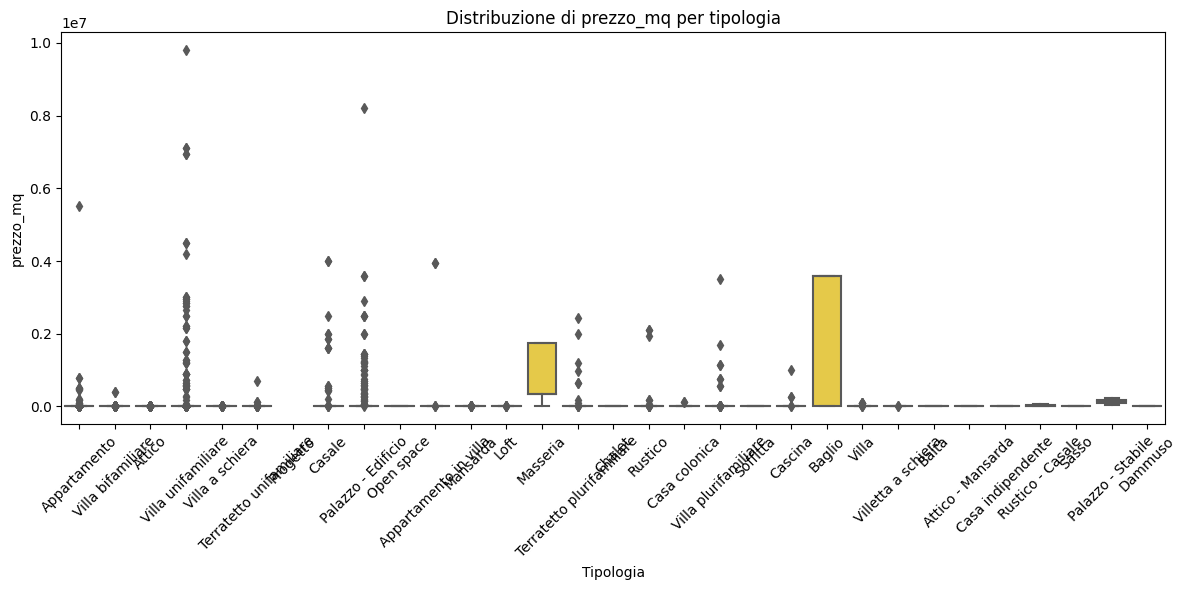

In [41]:
plot_boxplot_tipologia(df_clean, "prezzo_mq")

In [42]:
def plot_heatmap(df):
    plt.figure(figsize=(12,8))
    corr = df.select_dtypes(include=["float64", "int64"]).corr()
    sns.heatmap(
        corr,
        annot=True,
        cmap="viridis",
        linewidths=.5,
        fmt=".2f"
    )
    plt.title("Heatmap delle correlazioni numeriche")
    plt.tight_layout()
    plt.show()



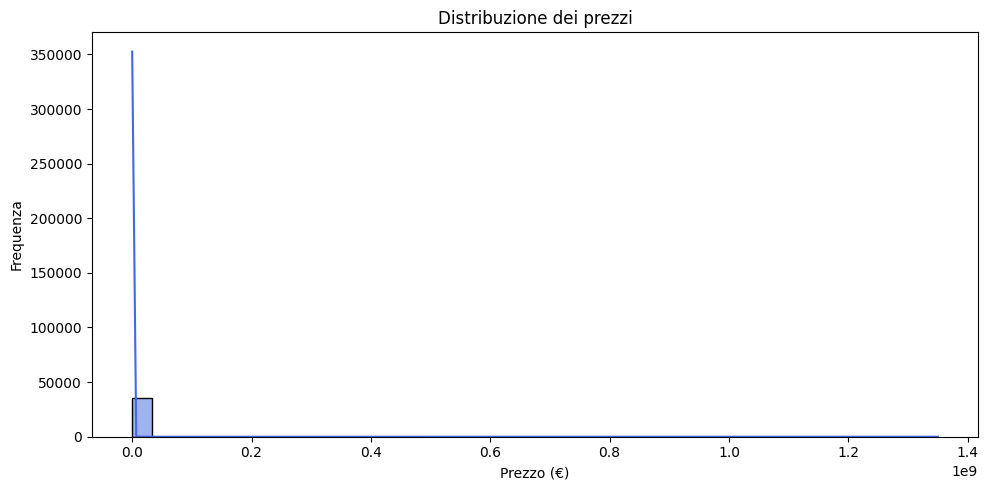

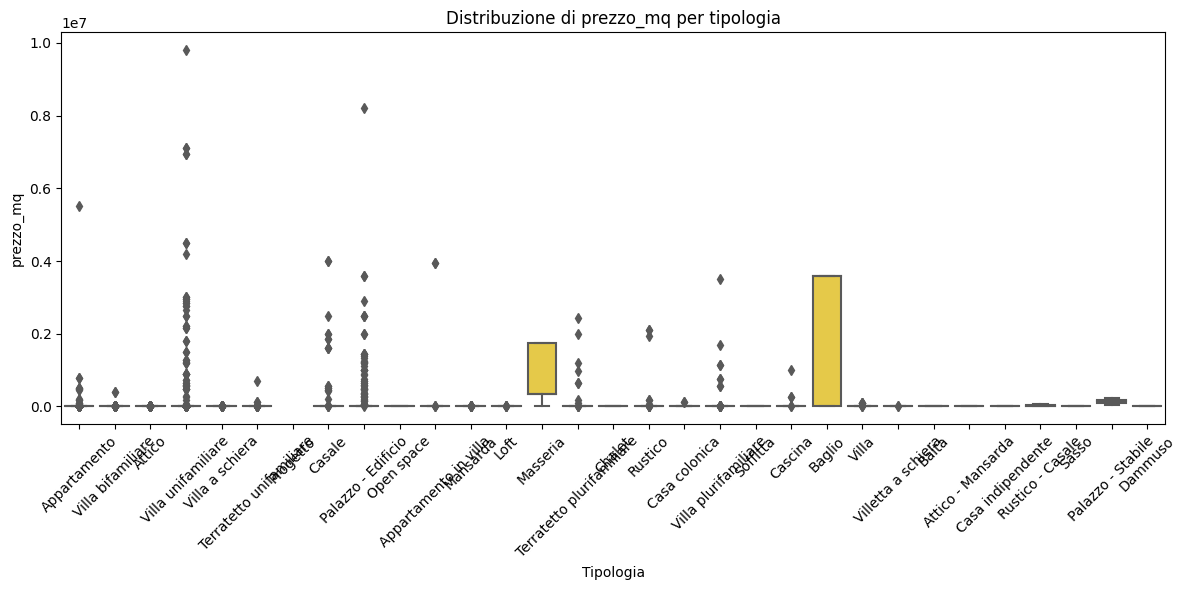

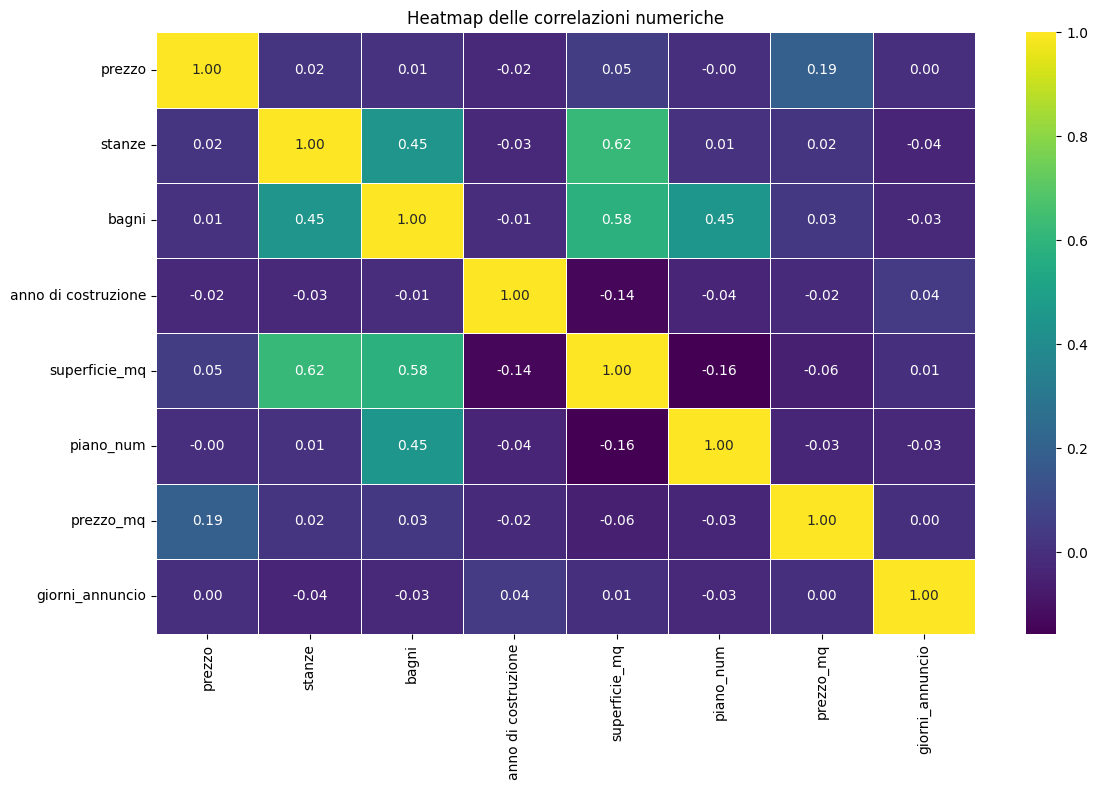

In [44]:
plot_distribuzione_prezzi(df_clean)
plot_boxplot_tipologia(df_clean, "prezzo_mq")
plot_heatmap(df_clean)

In [45]:
def plot_scatter_prezzo_superficie(df):
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=df,
        x="superficie_mq",
        y="prezzo",
        hue="categoria",
        palette="Set2",
        alpha=0.7
    )
    plt.title("Prezzo vs Superficie")
    plt.xlabel("Superficie (m²)")
    plt.ylabel("Prezzo (€)")
    plt.tight_layout()
    plt.show()

In [60]:
def plot_prezzi_per_zona(df, col_zona="regione"):
    plt.figure(figsize=(12,6))
    df_group = df.groupby(col_zona)["prezzo"].mean().sort_values()
    sns.barplot(x=df_group.index, y=df_group.values, palette="viridis")
    plt.title("Prezzo mediano per zona")
    plt.xlabel("regione")
    plt.ylabel("Prezzo mediano (€)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

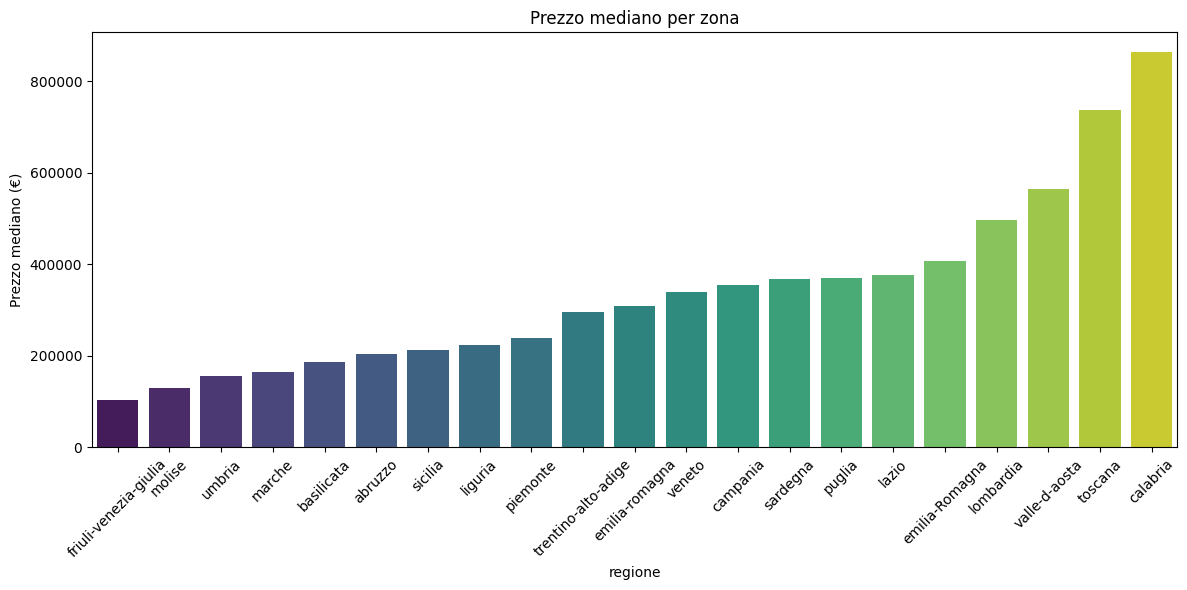

In [61]:
plot_prezzi_per_zona(df_clean, col_zona="regione")

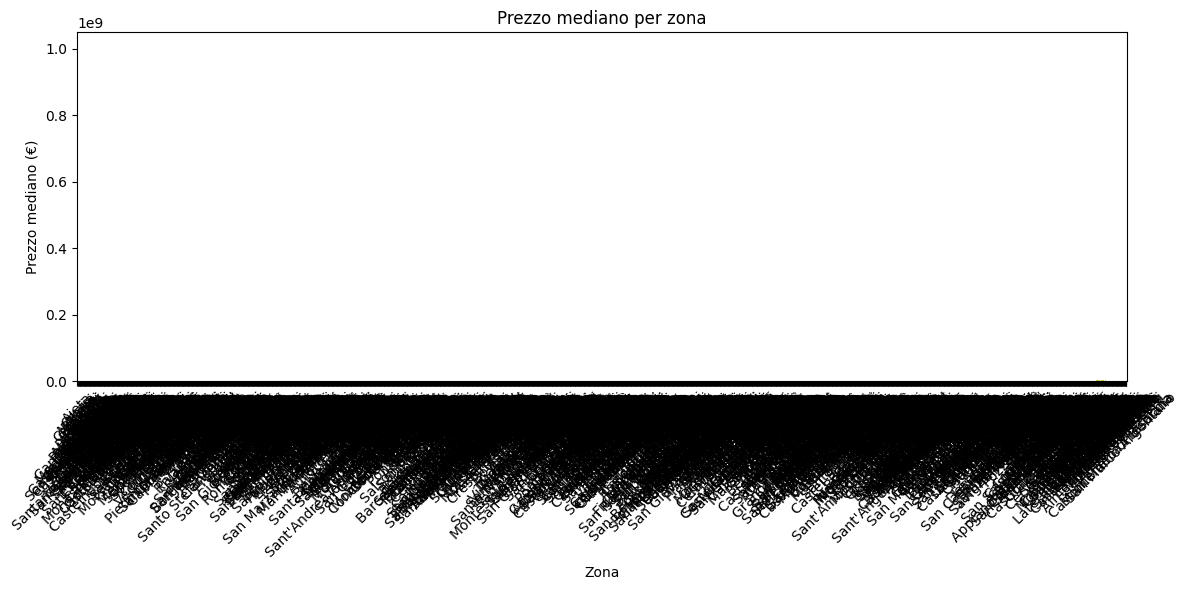

In [49]:
plot_prezzi_per_zona(df_clean, col_zona="citta")

In [50]:
def plot_trend_temporale(df):
    df_temp = (
        df.dropna(subset=["Data_annuncio"])
        .set_index("Data_annuncio")
        .resample("M")["prezzo"]
        .median()
    )

    plt.figure(figsize=(12,6))
    plt.plot(df_temp.index, df_temp.values, marker="o", color="royalblue")
    plt.title("Trend del prezzo mediano nel tempo")
    plt.xlabel("Data")
    plt.ylabel("Prezzo mediano (€)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [51]:
def report_eda_immobiliare(df):
    print("===== PANORAMICA GENERALE =====")
    print(df.describe(include="all"))
    print("\n===== VALORI MANCANTI =====")
    print(df.isna().sum())
    print("\n===== PRIME 5 RIGHE =====")
    display(df.head())

    # Distribuzione prezzi
    plot_distribuzione_prezzi(df)

    # Scatter prezzo vs superficie
    plot_scatter_prezzo_superficie(df)

    # Boxplot per tipologia
    plot_boxplot_tipologia(df, "prezzo_mq")

    # Heatmap correlazioni
    plot_heatmap(df)

    # Trend temporale
    if "Data_annuncio" in df.columns:
        plot_trend_temporale(df)

    print("\n===== REPORT COMPLETATO =====")

===== PANORAMICA GENERALE =====
              prezzo        stanze     m2         bagni        piano  \
count   3.553400e+04  29399.000000  36937  34112.000000        37087   
unique           NaN           NaN    934           NaN          822   
top              NaN           NaN  100m²           NaN  Piano terra   
freq             NaN           NaN   1302           NaN         4058   
first            NaN           NaN    NaN           NaN          NaN   
last             NaN           NaN    NaN           NaN          NaN   
mean    4.207344e+05      3.309602    NaN      1.819448          NaN   
std     1.037948e+07      1.092373    NaN      2.101824          NaN   
min     1.000000e+00      1.000000    NaN      1.000000          NaN   
25%     7.000000e+04      3.000000    NaN      1.000000          NaN   
50%     2.200000e+05      3.000000    NaN      2.000000          NaN   
75%     3.900000e+05      4.000000    NaN      2.000000          NaN   
max     1.350000e+09      5.0000

c:\Users\mrand\anaconda3\envs\rstudio\lib\site-packages\ipykernel_launcher.py:3: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  This is separate from the ipykernel package so we can avoid doing imports until


,prezzo,stanze,m2,bagni,piano,description,Riferimento e Data annuncio,contratto,tipologia,superficie,...,spese aggiuntive,Dati catastali,Altri dati catastali,superficie_mq,piano_num,riferimento,Data_annuncio,categoria,prezzo_mq,giorni_annuncio
0,78000.0,3.0,67m²,1.0,"Piano terra, con accesso disabili","Vendesi a Valledoria in Via Alessandro Volta, ...",Daniela - 17/12/2022,Vendita,Appartamento | Intera proprietà | Classe immob...,67 m² - Vedi dettaglio,...,NaN,NaN,NaN,67.0,0.0,Daniela,2022-12-17,Appartamento,1164.179104,1187
1,460000.0,3.0,75m²,2.0,1°,Nell’esclusivo comprensorio di Punta Aldìa in ...,698 - 31/03/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,75 m² - Vedi dettaglio,...,NaN,NaN,NaN,75.0,1.0,698,2023-03-31,Appartamento,6133.333333,1083
2,387000.0,4.0,160m²,2.0,"4° piano, con ascensore, con accesso disabili","Via Morgagni, zona residenziale e silenziosa, ...",Via Morgagni_ - 18/04/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,160 m²,...,NaN,NaN,NaN,160.0,4.0,Via Morgagni_,2023-04-18,Appartamento,2418.750000,1065
3,257000.0,5.0,136m²,2.0,"4° piano, con ascensore","Nella rinomata Fonsarda, precisamente in via G...",Via Giudicessa_ - 14/04/2023,Vendita,Appartamento | Intera proprietà | Classe immob...,136 m²,...,NaN,NaN,NaN,136.0,4.0,Via Giudicessa_,2023-04-14,Appartamento,1889.705882,1069
4,370000.0,3.0,105m²,2.0,"Piano terra, con accesso disabili",Luminosa villetta bifamiliare semindipendente ...,F3c sud - 31/03/2023,Vendita - Scarica capitolato,Villa bifamiliare | Intera proprietà | Immobil...,105 m² - Vedi dettaglio,...,NaN,NaN,NaN,105.0,0.0,F3c sud,2023-03-31,Villa bifamiliare,3523.809524,1083


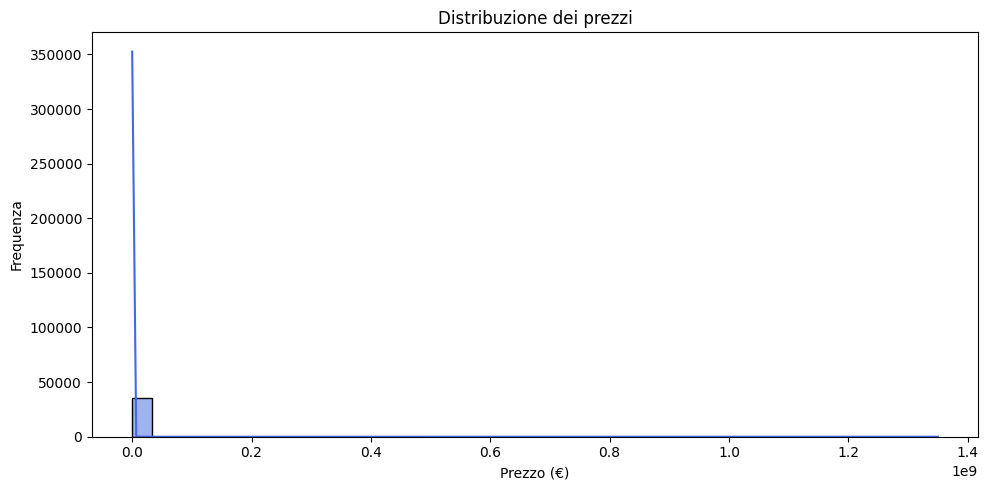

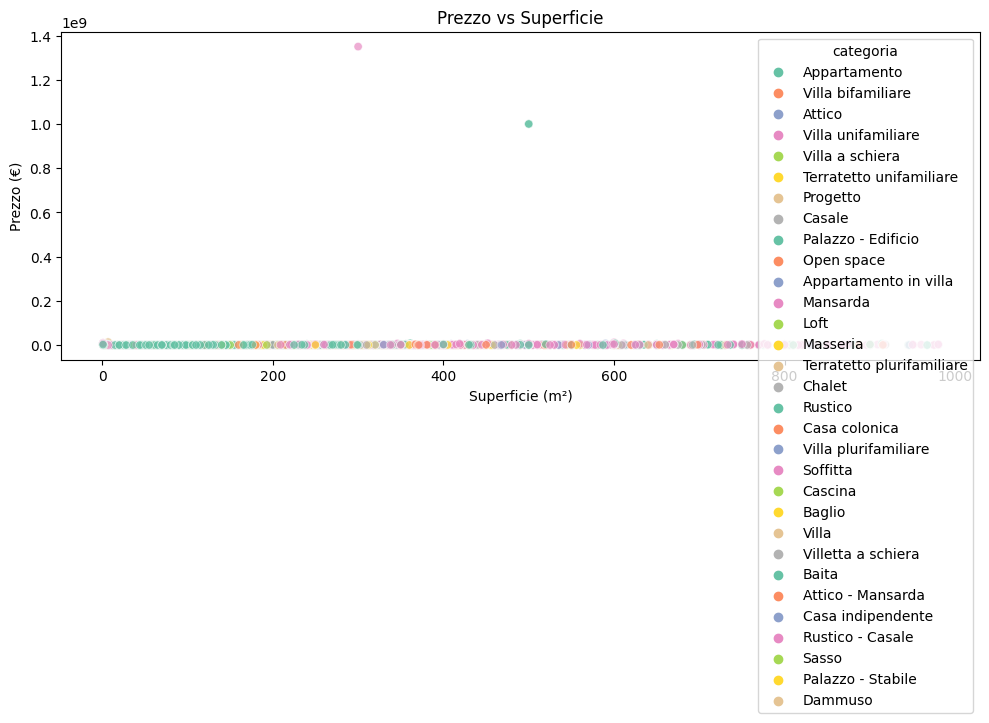

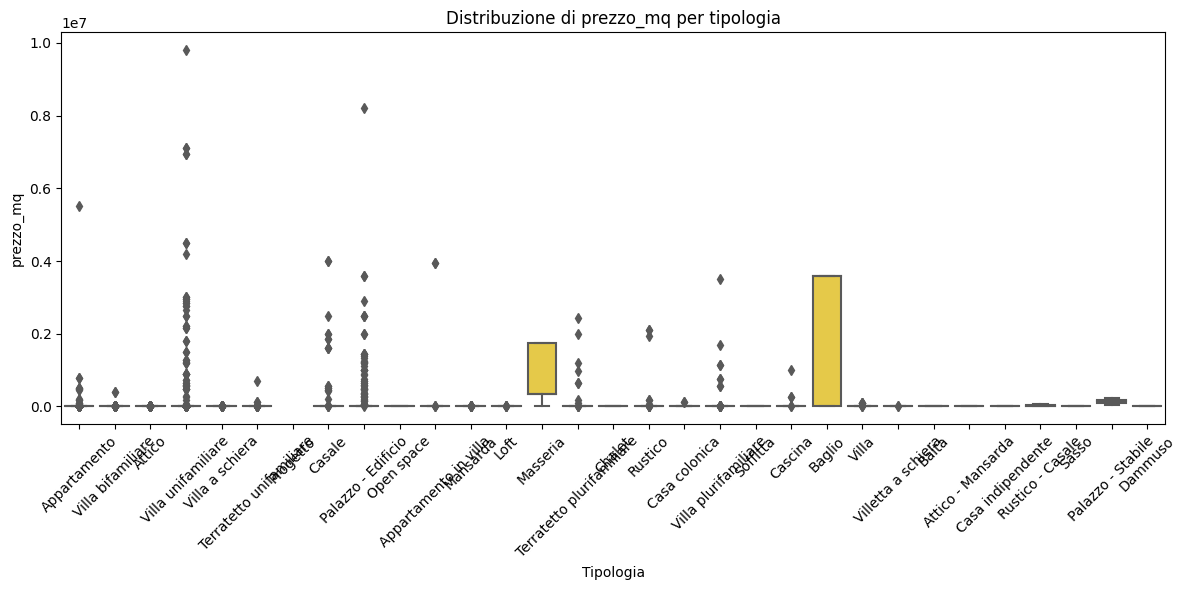

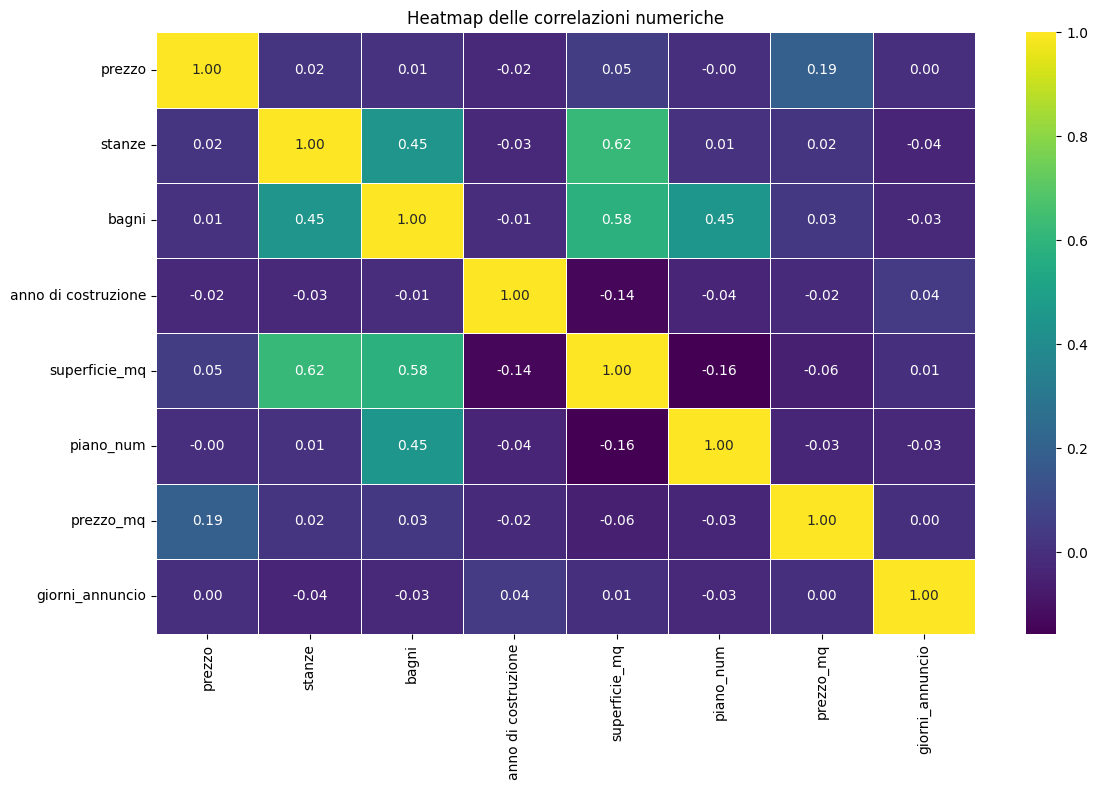

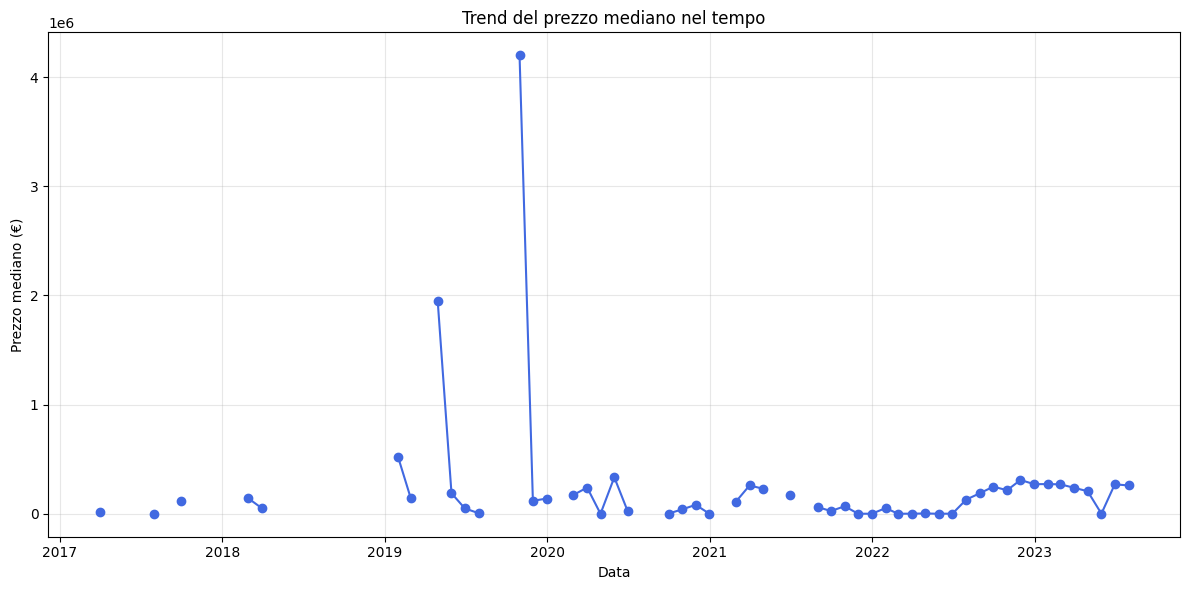


===== REPORT COMPLETATO =====


TypeError: 'NoneType' object is not callable

In [53]:
report_eda_immobiliare(df_clean)()